##Setup

In [8]:
!pip install gymnasium shimmy ale-py
!pip install autorom
!AutoROM -y

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/opt/anaconda3/lib/python3.13/site-packages/AutoROM/roms

Existing ROMs will be overwritten.


In [9]:
"""
live_plot.py — drop-in live metrics dashboard for Go-Explore notebooks.

Usage
-----
from live_plot import MetricsDashboard

dashboard = MetricsDashboard(metrics=['max_reward', 'cells', 'loss', 'entropy'])

# inside your training loop, replace print(...) with:
dashboard.update(
    iteration   = iterations,
    frames      = frames,
    max_reward  = highscore,
    cells       = len(archive),
    loss        = loss,
    entropy     = entropy,   # omit kwargs that don't apply to your algorithm
)
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from IPython import display as ipydisplay
from collections import defaultdict
import numpy as np

# ── Aesthetic config ──────────────────────────────────────────────────────────
BG       = '#0d1117'
PANEL_BG = '#161b22'
GRID_COL = '#21262d'
TEXT     = '#e6edf3'
MUTED    = '#8b949e'
BORDER   = '#30363d'

PALETTE = [
    '#58a6ff',   # blue       — max_reward
    '#3fb950',   # green      — cells
    '#f78166',   # red-orange — loss
    '#d2a8ff',   # lavender   — entropy
    '#ffa657',   # amber      — actor_loss
    '#79c0ff',   # light blue — critic_loss
]

# Human-readable labels for known metric keys
LABELS = {
    'max_reward'  : 'Max Reward',
    'cells'       : 'Archive Cells',
    'loss'        : 'Loss',
    'entropy'     : 'Entropy',
    'actor_loss'  : 'Actor Loss',
    'critic_loss' : 'Critic Loss',
    'epsilon'     : 'Epsilon',
    'frames'      : 'Frames',
}


class MetricsDashboard:
    """
    Live-updating matplotlib dashboard for Jupyter notebooks.

    Parameters
    ----------
    metrics : list[str]
        Names of the metrics to plot, e.g. ['max_reward', 'cells', 'loss'].
        Each gets its own subplot panel.
    title : str
        Dashboard title shown at the top.
    update_every : int
        Redraw the figure every N calls to .update(). Higher = faster training,
        less smooth graph. Default 1 redraws every iteration.
    window : int | None
        If set, only the last `window` iterations are shown (rolling view).
        None shows the full history.
    """

    def __init__(
        self,
        metrics       : list,
        title         : str  = 'Go-Explore Training',
        update_every  : int  = 1,
        window        : int | None = None,
    ):
        if not metrics:
            raise ValueError('Provide at least one metric name.')

        self.metrics      = metrics
        self.title        = title
        self.update_every = update_every
        self.window       = window
        self._call_count  = 0

        # History stores: iteration index + one list per metric
        self._iters : list[int]            = []
        self._data  : dict[str, list[float]] = defaultdict(list)

        matplotlib.rcParams.update({
            'font.family'      : 'monospace',
            'axes.facecolor'   : PANEL_BG,
            'figure.facecolor' : BG,
            'text.color'       : TEXT,
            'axes.labelcolor'  : MUTED,
            'xtick.color'      : MUTED,
            'ytick.color'      : MUTED,
            'axes.edgecolor'   : BORDER,
            'axes.grid'        : True,
            'grid.color'       : GRID_COL,
            'grid.linewidth'   : 0.6,
            'axes.spines.top'  : False,
            'axes.spines.right': False,
        })

        n    = len(metrics)
        cols = min(n, 2)
        rows = (n + 1) // 2

        self._fig = plt.figure(
            figsize    = (7 * cols, 3.2 * rows + 0.8),
            facecolor  = BG,
        )

        # Title row + metric panels
        outer = gridspec.GridSpec(
            2, 1,
            figure       = self._fig,
            height_ratios= [0.18, 1],
            hspace       = 0.05,
        )
        inner = gridspec.GridSpecFromSubplotSpec(
            rows, cols,
            subplot_spec = outer[1],
            hspace       = 0.55,
            wspace       = 0.35,
        )

        # Header panel (text only)
        self._header_ax = self._fig.add_subplot(outer[0])
        self._header_ax.axis('off')
        self._title_text = self._header_ax.text(
            0.5, 0.45, title,
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=15, fontweight='bold',
            color=TEXT, fontfamily='monospace',
        )
        self._subtitle_text = self._header_ax.text(
            0.5, -0.25, '',
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=9, color=MUTED, fontfamily='monospace',
        )

        # One subplot per metric
        self._axes = []
        self._lines = []
        for idx, metric in enumerate(metrics):
            row, col = divmod(idx, cols)
            ax = self._fig.add_subplot(inner[row, col])
            ax.set_title(
                LABELS.get(metric, metric),
                fontsize=10, color=MUTED,
                pad=6, loc='left',
            )
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.tick_params(labelsize=7)

            color = PALETTE[idx % len(PALETTE)]
            (line,) = ax.plot([], [], color=color, linewidth=1.6, antialiased=True)

            # Subtle fill under the curve
            ax.fill_between([], [], color=color, alpha=0.08)

            self._axes.append(ax)
            self._lines.append(line)

        # Hide any unused subplot slots
        for idx in range(len(metrics), rows * cols):
            row, col = divmod(idx, cols)
            self._fig.add_subplot(inner[row, col]).set_visible(False)

        plt.close(self._fig)   # Don't show yet; we control display manually

    # ─────────────────────────────────────────────────────────────────────────
    def update(self, iteration: int, frames: int = 0, **metric_values):
        """
        Record one data point and optionally redraw.

        Parameters
        ----------
        iteration : int
            Current training iteration (x-axis).
        frames : int
            Total environment frames so far (shown in subtitle).
            If 'frames' is also listed in the `metrics` list passed to
            __init__, it will be plotted as a panel too — the named parameter
            and the plottable metric are the same value.
        **metric_values
            Keyword arguments matching the `metrics` list passed to __init__.
            Unknown keys are silently ignored.
        """
        # FIX: 'frames' is an explicit named parameter used for the subtitle,
        # so passing frames=N never reaches **metric_values — it gets consumed
        # by the signature before ** sees it. If the user listed 'frames' as a
        # metric to plot, inject it back into the lookup dict here.
        if 'frames' in self.metrics:
            metric_values = {**metric_values, 'frames': frames}

        self._iters.append(iteration)
        for metric in self.metrics:
            value = metric_values.get(metric, float('nan'))
            self._data[metric].append(float(value))

        self._call_count += 1
        if self._call_count % self.update_every == 0:
            self._redraw(frames)

    # ─────────────────────────────────────────────────────────────────────────
    def _redraw(self, frames: int):
        iters = np.array(self._iters)

        if self.window is not None and len(iters) > self.window:
            iters = iters[-self.window:]
            data  = {m: self._data[m][-self.window:] for m in self.metrics}
        else:
            data = self._data

        # Update subtitle
        latest = {m: data[m][-1] for m in self.metrics if data[m]}
        parts  = [f'iter {iters[-1]:,}', f'frames {frames:,}']
        parts += [f"{LABELS.get(m, m)}: {v:.3g}" for m, v in latest.items()]
        #self._subtitle_text.set_text('  ·  '.join(parts))

        for ax, line, metric in zip(self._axes, self._lines, self.metrics):
            y = np.array(data[metric], dtype=float)

            # Remove old fill_between collections and redraw
            for coll in ax.collections:
                coll.remove()

            line.set_data(iters, y)

            color = line.get_color()
            ax.fill_between(iters, y, alpha=0.08, color=color)

            # Tight axis limits with padding
            valid = y[np.isfinite(y)]
            if len(valid) >= 2:
                ymin, ymax = valid.min(), valid.max()
                pad = (ymax - ymin) * 0.12 or 0.5
                ax.set_ylim(ymin - pad, ymax + pad)

            if len(iters) >= 2:
                ax.set_xlim(iters[0], iters[-1])

        ipydisplay.clear_output(wait=True)
        ipydisplay.display(self._fig)

    def final(self):
        """Call once at the end of training to ensure the final state is shown."""
        self._redraw(frames=self._iters[-1] if self._iters else 0)


def get_lives(env):
    """
    Read the current number of lives directly from the ALE emulator,
    bypassing the Gymnasium wrapper entirely.

    Why this matters:
    - Montezuma's Revenge reports info['lives'] as lives *remaining after
      the current one*, so a fresh episode starts at 5, not 6.
    - Checking `info['lives'] < 6` is therefore always True, terminating
      every episode on step 1 and freezing archive growth at ~8 cells.
    - After ale.restoreState() the wrapper's internal counter is stale
      (it only updates through env.reset()), making info['lives'] wrong
      for the entire restored episode too.
    - env.unwrapped.ale.lives() always reflects the true ALE state
      regardless of how the state was set.

    Usage pattern in training loop:
        current_lives = get_lives(env)          # after reset or restore
        ...
        new_lives = get_lives(env)              # after env.step()
        life_lost = new_lives < current_lives   # relative decrease only
        current_lives = new_lives
    """
    return env.unwrapped.ale.lives()

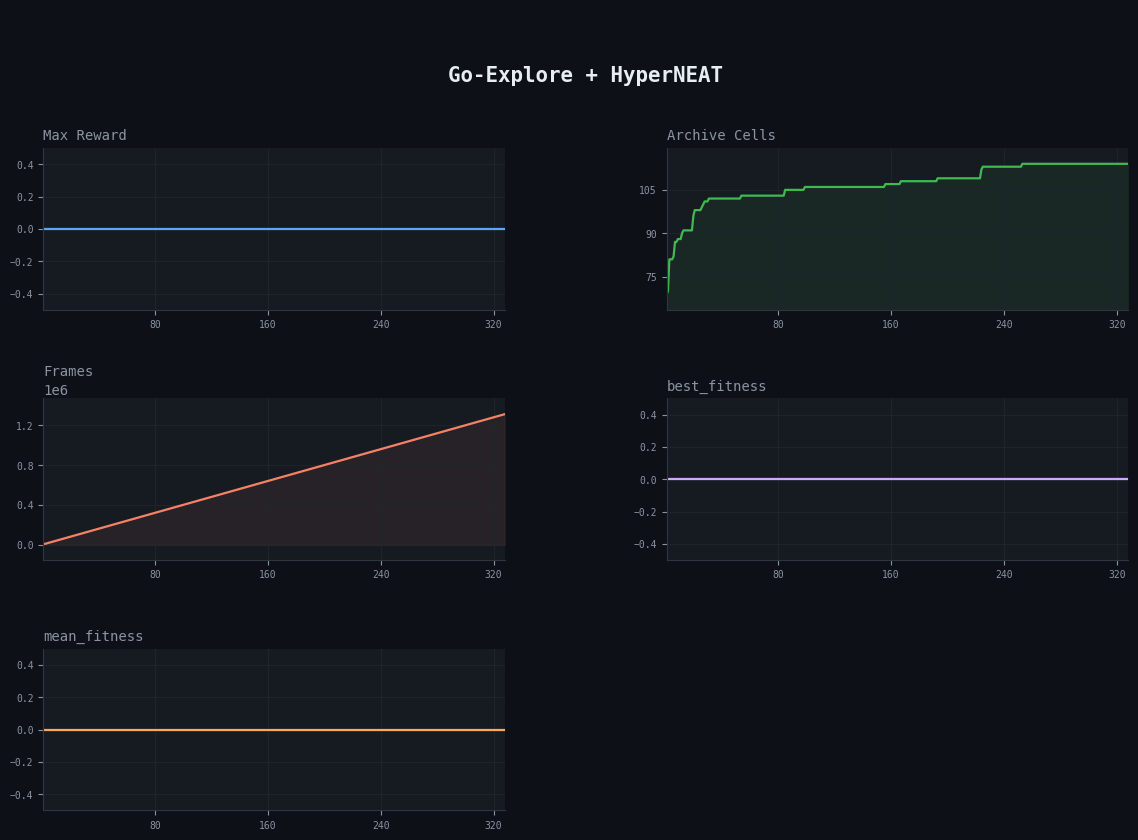

KeyboardInterrupt: 

In [10]:
from collections import defaultdict
import numpy as np
import cv2
import gymnasium as gym
import ale_py
import random
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

dashboard = MetricsDashboard(
    metrics=['max_reward', 'cells', 'frames', 'best_fitness', 'mean_fitness'],
    title='Go-Explore + HyperNEAT', update_every=1,
)

# ──────────────────────────────────────────────
# Go-Explore cell functions (pixel-based)
# ──────────────────────────────────────────────
def cellfn(frame):
    cell = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    cell = cv2.resize(cell, (11, 8), interpolation=cv2.INTER_AREA)
    cell = cell // 32
    return cell

def hashfn(cell):
    return hash(cell.tobytes())

# ──────────────────────────────────────────────
# Go-Explore archive
# ──────────────────────────────────────────────
e1 = 0.001
e2 = 0.00001

class Weights:
    times_chosen           = 0.1
    times_chosen_since_new = 0.0
    times_seen             = 0.3

class Powers:
    times_chosen           = 0.5
    times_chosen_since_new = 0.5
    times_seen             = 0.5

class Cell:
    def __init__(self):
        self.times_chosen           = 0
        self.times_chosen_since_new = 0
        self.times_seen             = 0

    def __setattr__(self, key, value):
        object.__setattr__(self, key, value)
        if key != 'score' and hasattr(self, 'times_seen'):
            self.score = self.cellscore()

    def cntscore(self, a):
        w = getattr(Weights, a)
        p = getattr(Powers, a)
        v = getattr(self, a)
        return w / (v + e1) ** p + e2

    def cellscore(self):
        return (self.cntscore('times_chosen') +
                self.cntscore('times_chosen_since_new') +
                self.cntscore('times_seen') + 1)

    def visit(self):
        self.times_seen += 1
        return self.times_seen == 1

    def choose(self):
        self.times_chosen           += 1
        self.times_chosen_since_new += 1
        return self.ram, self.reward, self.trajectory


# ──────────────────────────────────────────────
# CPPN — Compositional Pattern Producing Network
#
# The core of HyperNEAT. A CPPN is a small neural network that maps
# the geometric coordinates of two neurons to the weight connecting them:
#
#     w(i→j) = CPPN(x_i, y_i, x_j, y_j, d_ij)
#
# where (x_i, y_i) and (x_j, y_j) are the normalised positions of the
# pre- and post-synaptic neurons in their respective layers, and
# d_ij = sqrt((x_j-x_i)^2 + (y_j-y_i)^2) is their Euclidean distance.
#
# Why CPPNs use mixed activations:
#   - tanh produces smooth symmetric weight patterns
#   - sin/cos produce periodic patterns (useful for spatial periodicity
#     in convolutional-like weight sharing)
#   - gaussian produces localised patterns (nearby neurons get similar weights)
#   Using all four in different neurons lets the CPPN compose these primitives
#   into complex but structured weight patterns that plain MLPs cannot express.
#
# Why this is different from directly evolving weights:
#   - A policy network with 500k parameters has 500k degrees of freedom.
#   - A CPPN with 1k parameters generates all 500k weights from 5 inputs.
#   - The CPPN implicitly enforces geometric regularity: neurons at similar
#     positions in the substrate automatically get similar weights.
#   - This is a form of inductive bias — the hypothesis space is restricted
#     to weight patterns that have spatial structure.
#
# CPPN topology (fixed — full NEAT would also evolve this):
#   Input (5) → Hidden (32, mixed activations) → Hidden (16, tanh) → Output (1, tanh)
# ──────────────────────────────────────────────
class CPPN(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        # 5 inputs: x_pre, y_pre, x_post, y_post, distance
        self.fc1 = nn.Linear(5, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, 1)

    def forward(self, x):
        """
        x : (N, 5) tensor of [x_pre, y_pre, x_post, y_post, distance]
        Returns: (N, 1) weight values in [-1, 1]
        """
        # Mixed activations in layer 1: split into four groups and apply
        # sin, cos, tanh, and gaussian activations independently, then concat.
        h1 = self.fc1(x)
        q  = h1.shape[1] // 4
        h1 = torch.cat([
            torch.sin(h1[:, :q]),
            torch.cos(h1[:, q:2*q]),
            torch.tanh(h1[:, 2*q:3*q]),
            torch.exp(-h1[:, 3*q:] ** 2),    # gaussian activation
        ], dim=1)
        h2 = torch.tanh(self.fc2(h1))
        return torch.tanh(self.fc3(h2))      # output in [-1, 1]

    def get_params(self):
        return np.concatenate([p.data.cpu().numpy().ravel()
                               for p in self.parameters()])

    def set_params(self, flat_params):
        offset = 0
        for p in self.parameters():
            size = p.numel()
            p.data.copy_(
                torch.from_numpy(
                    flat_params[offset : offset + size].reshape(p.shape)
                ).float()
            )
            offset += size


# ──────────────────────────────────────────────
# Substrate
#
# Defines the geometric layout of neurons in each layer.
# Neurons are placed on a grid; their normalised (x, y) coordinates
# in [-1, 1] are passed to the CPPN.
#
# Layer substrates used here:
#   conv_out  : 2D spatial grid matching the conv feature map (H×W)
#   fc_hidden : 1D line from -1 to 1 (256 neurons at y=0)
#   fc_out    : 1D line from -1 to 1 (n_actions neurons at y=0)
#
# The CPPN is queried for every (pre, post) neuron pair within a connection.
# For large layers this can be expensive, so we batch all queries as a
# matrix multiply-like operation using torch.
# ──────────────────────────────────────────────
class Substrate:
    def __init__(self, conv_out_h, conv_out_w, conv_channels,
                 hidden_size, n_actions, device):
        self.device = device

        # Feature map neurons: (C, H, W) flattened to (C*H*W,) with 2D spatial coords
        # Each neuron's position is (x_col, y_row) normalised to [-1, 1]
        positions = []
        for c in range(conv_channels):
            for h in range(conv_out_h):
                for w in range(conv_out_w):
                    x = (w / (conv_out_w - 1)) * 2 - 1 if conv_out_w > 1 else 0.0
                    y = (h / (conv_out_h - 1)) * 2 - 1 if conv_out_h > 1 else 0.0
                    positions.append([x, y])
        self.feature_pos = torch.tensor(positions, dtype=torch.float32, device=device)

        # Hidden FC neurons: 1D line at y=0
        self.hidden_pos = torch.stack([
            torch.linspace(-1, 1, hidden_size, device=device),
            torch.zeros(hidden_size, device=device),
        ], dim=1)

        # Output neurons: 1D line at y=0
        self.out_pos = torch.stack([
            torch.linspace(-1, 1, n_actions, device=device),
            torch.zeros(n_actions, device=device),
        ], dim=1)

    def _query_weights(self, cppn, pre_pos, post_pos):
        """
        Query the CPPN for every (pre, post) neuron pair to produce a weight matrix.

        For N pre-neurons and M post-neurons this builds an (N*M, 5) input batch
        and returns a (N, M) weight matrix. The distance input provides the CPPN
        with information about how far apart the two neurons are geometrically.

        pre_pos  : (N, 2)  positions of pre-synaptic neurons
        post_pos : (M, 2)  positions of post-synaptic neurons
        Returns  : (N, M)  weight matrix
        """
        N, M = pre_pos.shape[0], post_pos.shape[0]

        # Broadcast to (N, M, 2)
        pre_exp  = pre_pos.unsqueeze(1).expand(N, M, 2)    # (N, M, 2)
        post_exp = post_pos.unsqueeze(0).expand(N, M, 2)   # (N, M, 2)

        dist = (post_exp - pre_exp).pow(2).sum(-1).sqrt()  # (N, M)

        # Build the (N*M, 5) input tensor
        coords = torch.cat([
            pre_exp.reshape(N * M, 2),
            post_exp.reshape(N * M, 2),
            dist.reshape(N * M, 1),
        ], dim=1)

        with torch.no_grad():
            weights = cppn(coords).reshape(N, M)

        return weights

    def generate_policy_weights(self, cppn, feature_size, hidden_size, n_actions):
        """
        Query the CPPN to produce all FC layer weights.

        Returns:
            fc1_w : (feature_size, hidden_size)
            fc1_b : (hidden_size,)
            fc2_w : (hidden_size, n_actions)
            fc2_b : (n_actions,)
        """
        # FC1: feature_pos → hidden_pos
        fc1_w = self._query_weights(cppn, self.feature_pos, self.hidden_pos)  # (F, H)

        # FC2: hidden_pos → out_pos
        fc2_w = self._query_weights(cppn, self.hidden_pos, self.out_pos)      # (H, A)

        # Biases: CPPN queried with zero pre-position (represents "bias neuron")
        bias_pre = torch.zeros(1, 2, device=self.device)
        fc1_b    = self._query_weights(cppn, bias_pre, self.hidden_pos).squeeze(0)
        fc2_b    = self._query_weights(cppn, bias_pre, self.out_pos).squeeze(0)

        return fc1_w, fc1_b, fc2_w, fc2_b


# ──────────────────────────────────────────────
# HyperNEAT Policy
#
# The policy network has two parts:
#   1. A fixed convolutional backbone — standard CNN used across all experiments.
#      The conv weights are not generated by the CPPN; they are evolved directly
#      as a flat parameter vector alongside the CPPN weights. This is a common
#      simplification since applying HyperNEAT to 2D conv kernels adds
#      significant substrate design complexity.
#
#   2. CPPN-generated FC layers — the FC weights are produced by the CPPN
#      using the substrate geometry. These are regenerated from scratch each
#      time set_cppn is called; no FC weights are stored in the network itself.
# ──────────────────────────────────────────────
class HyperNEATPolicy(nn.Module):
    def __init__(self, input_shape, n_actions, hidden_size=256):
        super().__init__()
        self.n_actions   = n_actions
        self.hidden_size = hidden_size

        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),             nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),             nn.ReLU(),
        )
        with torch.no_grad():
            dummy       = torch.zeros(1, *input_shape)
            conv_out    = self.conv(dummy)
            self.feature_size = conv_out.reshape(1, -1).size(1)
            # Record spatial dims for substrate (last conv layer has 64 channels)
            _, C, H, W  = conv_out.shape
            self.conv_out_h = H
            self.conv_out_w = W
            self.conv_channels = C

        # FC weight placeholders — set by set_cppn(), not learned
        self.fc1_w = None
        self.fc1_b = None
        self.fc2_w = None
        self.fc2_b = None

    def set_cppn(self, cppn, substrate):
        """Generate and cache the FC weights from the CPPN."""
        fw, fb, ow, ob = substrate.generate_policy_weights(
            cppn, self.feature_size, self.hidden_size, self.n_actions
        )
        self.fc1_w = fw   # (feature_size, hidden_size)
        self.fc1_b = fb   # (hidden_size,)
        self.fc2_w = ow   # (hidden_size, n_actions)
        self.fc2_b = ob   # (n_actions,)

    def forward(self, x):
        assert self.fc1_w is not None, "Call set_cppn() before forward()"
        x        = x.float() / 255.
        features = self.conv(x).reshape(x.size(0), -1)   # (B, feature_size)
        h        = torch.relu(features @ self.fc1_w + self.fc1_b)
        return h @ self.fc2_w + self.fc2_b

    def act(self, state_np, device):
        with torch.no_grad():
            t = torch.from_numpy(state_np).permute(2, 0, 1).unsqueeze(0).to(device)
            return self.forward(t).argmax(1).item()

    def get_conv_params(self):
        """Flat numpy vector of conv-only parameters."""
        return np.concatenate([p.data.cpu().numpy().ravel()
                               for p in self.conv.parameters()])

    def set_conv_params(self, flat_params):
        offset = 0
        for p in self.conv.parameters():
            size = p.numel()
            p.data.copy_(
                torch.from_numpy(
                    flat_params[offset : offset + size].reshape(p.shape)
                ).float()
            )
            offset += size


# ──────────────────────────────────────────────
# Genome
#
# An individual's genome = CPPN parameters + conv parameters concatenated
# into a single flat numpy vector. The CPPN parameters generate all FC
# weights via the substrate; the conv parameters are evolved directly.
# ──────────────────────────────────────────────
class Genome:
    def __init__(self, cppn_params, conv_params):
        self.cppn_params = cppn_params.copy()
        self.conv_params = conv_params.copy()

    def to_flat(self):
        return np.concatenate([self.cppn_params, self.conv_params])

    @staticmethod
    def from_flat(flat, cppn_size):
        return Genome(flat[:cppn_size], flat[cppn_size:])

    def mutate(self, sigma):
        """Return a new Genome with Gaussian noise added to all parameters."""
        return Genome(
            self.cppn_params + np.random.randn(*self.cppn_params.shape).astype(np.float32) * sigma,
            self.conv_params  + np.random.randn(*self.conv_params.shape).astype(np.float32) * sigma,
        )


# ──────────────────────────────────────────────
# HyperNEAT GA
#
# Full NEAT evolves the CPPN topology (adding nodes and edges) using
# speciation and crossover. This is a significant implementation — we
# use a simpler fixed-topology GA that evolves only the CPPN weights,
# which captures HyperNEAT's geometric weight generation while remaining
# practical to implement from scratch.
# ──────────────────────────────────────────────
class HyperNEATGA:
    def __init__(self, pop_size, elite_frac, sigma):
        self.pop_size = pop_size
        self.n_elites = max(1, int(pop_size * elite_frac))
        self.sigma    = sigma
        self.population = []   # list of Genome

    def seed(self, template_genome):
        self.population = [template_genome.mutate(self.sigma)
                           for _ in range(self.pop_size)]
        self.population[0] = copy.deepcopy(template_genome)   # keep one clean copy

    def evolve(self, fitnesses):
        """
        Truncation selection + mutation. Returns elite genomes for logging.
        """
        ranked = sorted(range(self.pop_size),
                        key=lambda i: fitnesses[i], reverse=True)
        elites = [self.population[i] for i in ranked[:self.n_elites]]

        next_pop = [copy.deepcopy(elites[0])]   # elitism
        while len(next_pop) < self.pop_size:
            parent = random.choice(elites)
            next_pop.append(parent.mutate(self.sigma))

        self.population = next_pop
        return elites


# ──────────────────────────────────────────────
# State restoration
# ──────────────────────────────────────────────
def restore_env(env, ram):
    env.unwrapped.ale.restoreState(ram)
    return env.unwrapped.ale.getScreenRGB()


def select_cell_from_archive(archive):
    hashes = list(archive.keys())
    scores = np.array([archive[h].score for h in hashes])
    probs  = scores / scores.sum()
    return hashes[np.random.choice(len(hashes), p=probs)]


# ──────────────────────────────────────────────
# Evaluate one genome
# ──────────────────────────────────────────────
def evaluate_genome(env, genome, policy, cppn, substrate, device,
                    archive, start_ram, start_score, start_trajectory, eval_steps):
    """
    Load genome into policy and CPPN, then run one rollout.
    Returns (fitness, found_new_cell).
    """
    # Load genome into the CPPN and conv backbone
    cppn.set_params(genome.cppn_params)
    policy.set_conv_params(genome.conv_params)

    # Generate FC weights from the CPPN via the substrate geometry
    policy.set_cppn(cppn, substrate)

    state         = restore_env(env, start_ram)
    score         = start_score
    trajectory    = start_trajectory.copy()
    current_lives = get_lives(env)
    found_new     = False

    for _ in range(eval_steps):
        action     = policy.act(state, device)
        next_state, reward, terminal, truncated, _ = env.step(action)

        new_lives = get_lives(env)
        life_lost = new_lives < current_lives
        done      = terminal or truncated or life_lost
        current_lives = new_lives

        score += reward
        trajectory.append(action)

        if done:
            break

        cell_repr   = cellfn(next_state)
        cellhash    = hashfn(cell_repr)
        cell        = archive[cellhash]
        first_visit = cell.visit()

        cell_reward = getattr(cell, 'reward',     -1e9)
        cell_traj   = getattr(cell, 'trajectory', [])
        better  = score > cell_reward
        shorter = score == cell_reward and len(trajectory) < len(cell_traj)

        if first_visit or better or shorter:
            cell.ram        = env.unwrapped.ale.cloneState()
            cell.reward     = score
            cell.trajectory = trajectory.copy()
            cell.times_chosen           = 0
            cell.times_chosen_since_new = 0
            found_new = True

        state = next_state

    fitness = score - start_score
    return fitness, found_new


# ──────────────────────────────────────────────
# Hyperparameters
# ──────────────────────────────────────────────
POP_SIZE    = 20
ELITE_FRAC  = 0.2
SIGMA       = 0.01
EVAL_STEPS  = 200
WARMUP_GENS = 10
HIDDEN_SIZE = 256   # FC hidden layer size (determines substrate geometry)

# ──────────────────────────────────────────────
# Setup
# ──────────────────────────────────────────────
archive   = defaultdict(lambda: Cell())
highscore = 0
frames    = 0

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

env         = gym.make('ALE/MontezumaRevenge-v5', render_mode='rgb_array')
obs         = env.observation_space.shape
n_actions   = env.action_space.n
input_shape = (obs[2], obs[0], obs[1])

# Build shared policy, CPPN, and substrate
policy = HyperNEATPolicy(input_shape, n_actions, HIDDEN_SIZE).to(device)
cppn   = CPPN(hidden_size=32).to(device)

substrate = Substrate(
    conv_out_h    = policy.conv_out_h,
    conv_out_w    = policy.conv_out_w,
    conv_channels = policy.conv_channels,
    hidden_size   = HIDDEN_SIZE,
    n_actions     = n_actions,
    device        = device,
)

# Seed the archive with a short random episode
state, _      = env.reset()
current_lives = get_lives(env)
seed_score    = 0
seed_traj     = []
for _ in range(500):
    action = env.action_space.sample()
    next_state, reward, terminal, truncated, _ = env.step(action)
    new_lives  = get_lives(env)
    done       = terminal or truncated or new_lives < current_lives
    current_lives = new_lives
    seed_score += reward
    seed_traj.append(action)
    frames += 1
    if not done:
        h = hashfn(cellfn(next_state))
        cell = archive[h]
        first_visit = cell.visit()
        if first_visit or seed_score > getattr(cell, 'reward', -1e9):
            cell.ram        = env.unwrapped.ale.cloneState()
            cell.reward     = seed_score
            cell.trajectory = seed_traj.copy()
            cell.times_chosen           = 0
            cell.times_chosen_since_new = 0
        state = next_state
    else:
        state, _      = env.reset()
        current_lives = get_lives(env)
        seed_score    = 0
        seed_traj     = []

# Initialise GA population with random genomes
template_genome = Genome(
    cppn_params = cppn.get_params(),
    conv_params = policy.get_conv_params(),
)
ga = HyperNEATGA(POP_SIZE, ELITE_FRAC, SIGMA)
ga.seed(template_genome)

generation = 0

# ──────────────────────────────────────────────
# Main loop — one iteration = one generation
# ──────────────────────────────────────────────
while True:
    fitnesses     = []
    found_new_any = False

    for genome in ga.population:
        if len(archive) > 0:
            h    = select_cell_from_archive(archive)
            cell = archive[h]
            ram, start_score, start_traj = cell.choose()
        else:
            env.reset()
            ram, start_score, start_traj = env.unwrapped.ale.cloneState(), 0, []

        fitness, found_new = evaluate_genome(
            env, genome, policy, cppn, substrate, device,
            archive, ram, start_score, start_traj, EVAL_STEPS
        )
        fitnesses.append(fitness)
        frames += EVAL_STEPS

        if start_score + fitness > highscore:
            highscore = start_score + fitness

        if found_new:
            found_new_any = True

    if generation >= WARMUP_GENS:
        ga.evolve(fitnesses)

    best_fitness = float(max(fitnesses))
    mean_fitness = float(np.mean(fitnesses))
    generation  += 1

    print(
        f"Gen: {generation:5d} | Cells: {len(archive):5d} | "
        f"Frames: {frames:8d} | MaxReward: {highscore:.1f} | "
        f"BestFit: {best_fitness:.2f} | MeanFit: {mean_fitness:.2f}"
    )

    dashboard.update(
        iteration    = generation,
        frames       = frames,
        max_reward   = highscore,
        cells        = len(archive),
        best_fitness = best_fitness,
        mean_fitness = mean_fitness,
    )